In [1]:
import numpy as np
from pyfield.utilities.matlab import mat_struct_to_dict, explore_mat


%load_ext autoreload
%autoreload 2

Settings:

# 1. Import .mat and .npz


In [2]:
def MSE(a, b):
    return np.square(np.subtract(a, b)).mean()

In [3]:
def get_comparison_data(mat_dict, npz_dict):
    
    # Extract pressure fields
    pr_fieldii = mat_dict['pr']
    pr_naive = npz_dict["pr_naive"]/npz_dict["pr_naive"].max()
    pr_sdi = npz_dict["pr_sdi"]/npz_dict["pr_sdi"].max()
    pr_auto = npz_dict["pr_auto"]/npz_dict["pr_auto"].max()
    # Extract times
    t_fieldii = mat_dict['mean_time']
    t_naive = npz_dict['time_naive'] 
    t_sdi = npz_dict['time_sdi']
    t_auto = npz_dict['time_auto']
    std_fieldii = mat_dict['std_time']
    std_naive = npz_dict['std_naive']
    std_sdi = npz_dict['std_sdi']
    std_auto = npz_dict['std_auto']

    # ---------- Compute MSE ---------
    mse_naive = MSE(pr_naive, pr_fieldii)
    mse_sdi = MSE(pr_sdi, pr_fieldii)
    mse_auto = MSE(pr_auto, pr_fieldii)

    return mse_naive, mse_sdi, mse_auto, t_fieldii, t_naive, t_sdi, t_auto, std_fieldii, std_naive, std_sdi, std_auto

In [4]:
import pandas as pd
from IPython.display import display, HTML

def make_table(table_values, table_titles, table_subtitles):
    # Build MultiIndex columns matching your layout
    col_tuples = []
    col_tuples.extend([(table_titles[0], s) for s in table_subtitles[0:5]])        # '', M,P,T,delta k, 8+2 T/M
    col_tuples.append((table_titles[1], table_subtitles[5]))                       # FIELDII -> t_FieldII
    col_tuples.extend([(table_titles[2], s) for s in table_subtitles[6:8]])       # PyField Naive -> t, MSE
    col_tuples.extend([(table_titles[3], s) for s in table_subtitles[8:10]])      # PyField SDI -> t, MSE
    col_tuples.extend([(table_titles[4], s) for s in table_subtitles[10:12]])     # PyField Auto -> t, MSE
    col_tuples.extend([(table_titles[5], s) for s in table_subtitles[12:15]])      # xSpeedup -> Naive, SDI, Auto

    columns = pd.MultiIndex.from_tuples(col_tuples)
    df = pd.DataFrame(table_values, columns=columns)

    # Show in notebook (markdown + HTML)
    # print(df.to_markdown(index=False))
    # display(HTML(df.to_html(index=False)))
    return df

## 1.1. Linear array

In [7]:
from pathlib import Path
from scipy import io as sio

# ---------- find .mat file(s) ---------
BASELINEAR = Path(r".\data\Linear")
BASEMATRIX = Path(r".\data\Matrix")
mats_linear = list(BASELINEAR.glob("*.mat"))
mats_matrix = list(BASEMATRIX.glob("*.mat"))

for i, mat_path in enumerate(mats_linear):
    print(f"idx {i}: {mat_path.name}")

for i, mat_path in enumerate(mats_matrix):
    print(f"idx {i}: {mat_path.name}")

# Order of mats:
#      [       P        ,    T   ,  M  ]
order_idx_linear =[3, 1, 2, 8, 6, 7, 0, 1, 4, 1, 5]
order_idx_matrix =[2, 0, 1, 0, 3, 4, 0, 5, 6]

idx 0: Linear_nsubx1_nsuby10_fs100_nxyz41_P68921_M1280_T725.mat
idx 1: Linear_nsubx1_nsuby10_fs200_nxyz41_P68921_M1280_T1444.mat
idx 2: Linear_nsubx1_nsuby10_fs200_nxyz81_P531441_M1280_T1444.mat
idx 3: Linear_nsubx1_nsuby10_fs200_nxyz9_P729_M1280_T1443.mat
idx 4: Linear_nsubx1_nsuby10_fs300_nxyz41_P68921_M1280_T2164.mat
idx 5: Linear_nsubx2_nsuby20_fs200_nxyz41_P68921_M5120_T1444.mat
idx 6: Linear_nsubx2_nsuby20_fs300_nxyz41_P68921_M5120_T2164.mat
idx 7: Linear_nsubx2_nsuby20_fs300_nxyz81_P531441_M5120_T2164.mat
idx 8: Linear_nsubx2_nsuby20_fs300_nxyz9_P729_M5120_T2162.mat
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
idx 1: Matrix_nsubx1_nsuby1_fs100_nxyz81_P531441_M3025_T767.mat
idx 2: Matrix_nsubx1_nsuby1_fs100_nxyz9_P729_M3025_T767.mat
idx 3: Matrix_nsubx1_nsuby1_fs200_nxyz41_P68921_M3025_T1525.mat
idx 4: Matrix_nsubx1_nsuby1_fs300_nxyz41_P68921_M3025_T2287.mat
idx 5: Matrix_nsubx2_nsuby2_fs100_nxyz41_P68921_M12100_T767.mat
idx 6: Matrix_nsubx3_nsuby3_fs100_nxyz41_

In [14]:
# ---------- prepare table -------
table_titles =    [    ''                                 ,'FIELDII', 'PyField Naive'  ,  'PyField SDI'    ,  'PyField Auto'  ,      "xSpeedup"       ]
table_subtitles = ["P", "T", "M", r"$\Delta k$", "8+2 T/M","t (s)", "t (s)", "MSE (%)", "t (s)", "MSE (%)", "t (s)", "MSE (%)", "Naive", "SDI", "Auto"]
table_values_linear = np.empty((len(order_idx_linear), len(table_subtitles)), dtype=object)

counter = 0

linear_mean_times = np.zeros((len(order_idx_linear), 4))  # To store times for FIELDII, Naive, SDI, Auto
linear_std_times = np.zeros((len(order_idx_linear), 4))   # To store std times for FIELDII, Naive, SDI, Auto

for i in order_idx_linear:
    mat_path = mats_linear[i]
    print(f"idx {i}: {mat_path.name}")

    #  ---------- load pyfield data ---------
    npz_path = mat_path.parent / (mat_path.stem + "_pyfield.npz")
    npz_dict = np.load(str(npz_path), allow_pickle=True)

    #  ---------- load fieldII data ---------
    mat_struct = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)['data']

    # If you want a Python-native copy:
    mat_dict = mat_struct_to_dict(mat_struct)

    #  ---------- get comparison data ---------
    (mse_naive, mse_sdi, mse_auto,
     t_fieldii, t_naive, t_sdi, t_auto,
     std_fieldii, std_naive, std_sdi, std_auto) = get_comparison_data(mat_dict, npz_dict)
    
    linear_mean_times[counter, :] = [t_fieldii, t_naive, t_sdi, t_auto]
    linear_std_times[counter, :] = [std_fieldii, std_naive, std_sdi, std_auto]

    #  ---------- fill table values ---------
    table_line = [npz_dict['P'],
                  npz_dict['T'],
                  npz_dict['M'],
                  f"{npz_dict['deltak']:.2f}",
                  f"{8 + 2 * npz_dict['T']/npz_dict['M']:.2f}",
                  f"{t_fieldii:.3f} ± {std_fieldii:.3f}",
                  f"{t_naive:.3f} ± {std_naive:.3f}",
                  f"{mse_naive*100:.4f}",
                  f"{t_sdi:.3f} ± {std_sdi:.3f}",
                  f"{mse_sdi*100:.4f}",
                  f"{t_auto:.3f} ± {std_auto:.3f}",
                  f"{mse_auto*100:.4f}",
                  f"{t_fieldii/t_naive:.2f}",
                  f"{t_fieldii/t_sdi:.2f}",
                  f"{t_fieldii/t_auto:.2f}",
                  ]
    table_values_linear[counter, :] = table_line

    # print(npz_dict['h_calc_time'])
    print(npz_dict['h_calc_time'])
    counter += 1


idx 3: Linear_nsubx1_nsuby10_fs200_nxyz9_P729_M1280_T1443.mat
[0.00697827 0.01597524 0.01031899 0.01054788 0.01928687 0.00963783
 0.01811099 0.01738548 0.00570273 0.00470781 0.01920295 0.01835537
 0.01812744 0.00544524 0.0159688  0.01569247 0.01311088 0.01597095
 0.00853205 0.00628567 0.01579976]
idx 1: Linear_nsubx1_nsuby10_fs200_nxyz41_P68921_M1280_T1444.mat
[0.45924854 0.47460771 0.45542002 0.47244549 0.50593686 0.49056721
 0.49757957 0.33400273 0.35753107 0.34932184 0.37422729 0.36382318
 0.36319518 0.34736156 0.41046834 0.38481665 0.42130685 0.38035965
 0.4273901  0.41335034 0.42803741]
idx 2: Linear_nsubx1_nsuby10_fs200_nxyz81_P531441_M1280_T1444.mat
[3.48514652 3.88835788 3.80427861 3.78632712 3.76315928 3.76316142
 3.63055158 2.75493383 2.75547171 2.70706797 2.58181334 2.70227027
 2.72016883 2.64493012 3.05019283 3.12147737 3.06845903 2.98445058
 3.07194114 2.976789   2.99595237]
idx 8: Linear_nsubx2_nsuby20_fs300_nxyz9_P729_M5120_T2162.mat
[0.02013731 0.0243876  0.02349114 0.0

In [9]:
make_table(table_values_linear, table_titles, table_subtitles)

FIELDII   PyField Naive  \
         P     T     M $\Delta k$ 8+2 T/M            t (s)           t (s)   
0      729  2066  1280      12.81   11.23    0.089 ± 0.001   0.013 ± 0.003   
1    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
2   531441  2067  1280      12.60   11.23   64.106 ± 1.174   3.749 ± 0.061   
3      729  3078  5120      11.36    9.20    0.200 ± 0.001   0.021 ± 0.001   
4    68921  3079  5120      11.25    9.20   18.559 ± 0.478   1.545 ± 0.025   
5   531441  3079  5120      11.24    9.20  142.778 ± 1.762  11.660 ± 0.052   
6    68921  1034  1280      10.26    9.62    6.932 ± 0.017   0.355 ± 0.005   
7    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
8    68921  3100  1280      15.93   12.84    9.341 ± 0.024   0.633 ± 0.017   
9    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
10   68921  2053  5120      10.26    8.80   16.809 ± 0.083   1.342 ± 0.006   

              PyField SDI           PyField Auto         xSpeedup         \
   MSE (%)          t (s) MSE (%)          t (s) MSE (%)    Naive    SDI   
0   0.0026  0.013 ± 0.006  0.0026  0.014 ± 0.003  0.0026     6.89   6.85   
1   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
2   0.0027  2.706 ± 0.036  0.0027  3.034 ± 0.037  0.0027    17.10  23.69   
3   0.0021  0.024 ± 0.002  0.0021  0.017 ± 0.002  0.0021     9.47   8.22   
4   0.0033  1.155 ± 0.010  0.0033  1.174 ± 0.011  0.0033    12.01  16.07   
5   0.0023  8.588 ± 0.038  0.0023  8.665 ± 0.067  0.0023    12.25  16.62   
6   0.0112  0.297 ± 0.006  0.0112  0.300 ± 0.005  0.0112    19.52  23.36   
7   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
8   0.0033  0.394 ± 0.011  0.0033  0.450 ± 0.021  0.0033    14.76  23.69   
9   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
10  0.0035  1.092 ± 0.021  0.0035  1.100 ± 0.001  0.0035    12.52  15.39   

           
     Auto  
0    6.44  
1   20.36  
2   21.13  
3   11.52  
4   15.81  
5   16.48  
6   23.14  
7   20.36  
8   20.75  
9   20.36  
10  15.28

## 1.2. Matrix array

In [15]:
table_values_matrix = np.empty((len(order_idx_matrix), len(table_subtitles)), dtype=object)

counter = 0
matrix_mean_times = np.zeros((len(order_idx_matrix), 4))  # To store times for FIELDII, Naive, SDI, Auto
matrix_std_times = np.zeros((len(order_idx_matrix), 4))   # To store std times for FIELDII, Naive, SDI, Auto

for i in order_idx_matrix:
    mat_path = mats_matrix[i]
    print(f"idx {i}: {mat_path.name}")

    #  ---------- load pyfield data ---------
    npz_path = mat_path.parent / (mat_path.stem + "_pyfield.npz")
    npz_dict = np.load(str(npz_path), allow_pickle=True)

    #  ---------- load fieldII data ---------
    mat_struct = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)['data']

    # If you want a Python-native copy:
    mat_dict = mat_struct_to_dict(mat_struct)

    #  ---------- get comparison data ---------
    (mse_naive, mse_sdi, mse_auto,
     t_fieldii, t_naive, t_sdi, t_auto,
     std_fieldii, std_naive, std_sdi, std_auto) = get_comparison_data(mat_dict, npz_dict)
    
    matrix_mean_times[counter, :] = [t_fieldii, t_naive, t_sdi, t_auto]
    matrix_std_times[counter, :] = [std_fieldii, std_naive, std_sdi, std_auto]
    
    print(f"w_c = 8 c/ fs : {8*npz_dict['c']/npz_dict['sampling_frequency']*1000:.2f} mm, and w_x, w_x = {npz_dict['tx_element_width_mm']:.2f}, {npz_dict['tx_element_height_mm']:.2f} mm")

    #  ---------- fill table values ---------
    table_line = [npz_dict['P'],
                  npz_dict['T'],
                  npz_dict['M'],
                  f"{npz_dict['deltak']:.2f}",
                  f"{8 + 2 * npz_dict['T']/npz_dict['M']:.2f}",
                  f"{t_fieldii:.3f} ± {std_fieldii:.3f}",
                  f"{t_naive:.3f} ± {std_naive:.3f}",
                  f"{mse_naive*100:.4f}",
                  f"{t_sdi:.3f} ± {std_sdi:.3f}",
                  f"{mse_sdi*100:.4f}",
                  f"{t_auto:.3f} ± {std_auto:.3f}",
                  f"{mse_auto*100:.4f}",
                  f"{t_fieldii/t_naive:.2f}",
                  f"{t_fieldii/t_sdi:.2f}",
                  f"{t_fieldii/t_auto:.2f}",
                  ]
    table_values_matrix[counter, :] = table_line

    # print(npz_dict['h_calc_time'])
    print("speedup PyField vs FieldII (naive, sdi, auto): {:.2f}x, {:.2f}x, {:.2f}x".format(
        t_fieldii / t_naive,
        t_fieldii / t_sdi,
        t_fieldii / t_auto
    ))
    counter += 1

idx 2: Matrix_nsubx1_nsuby1_fs100_nxyz9_P729_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 50.68x, 59.51x, 79.39x
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 70.51x, 135.07x, 133.52x
idx 1: Matrix_nsubx1_nsuby1_fs100_nxyz81_P531441_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 68.19x, 132.12x, 131.08x
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 70.51x, 135.07x, 133.52x
idx 3: Matrix_nsubx1_nsuby1_fs200_nxyz41_P68921_M3025_T1525.mat
w_c = 8 c/ fs : 0.06 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 49.39x, 134.57x, 130.02x
idx 4: Matrix_nsubx1_nsuby1_fs300_nxyz41_P68921_M3025_T228

In [11]:
make_table(table_values_matrix, table_titles, table_subtitles)

FIELDII  PyField Naive  \
        P     T      M $\Delta k$ 8+2 T/M            t (s)          t (s)   
0     729  1485   3025      18.06    8.98    0.899 ± 0.004  0.018 ± 0.003   
1   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
2  531441  1485   3025      17.95    8.98  648.655 ± 2.396  9.512 ± 0.069   
3   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
4   68921  2970   3025      32.45    9.96   96.962 ± 0.990  1.963 ± 0.021   
5   68921  4455   3025      47.27   10.95  108.164 ± 1.944  2.701 ± 0.036   
6   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
7   68921  1471  12100      11.53    8.24  110.910 ± 0.434  3.365 ± 0.024   
8   68921  1467  27225      10.21    8.11  149.683 ± 1.184  6.748 ± 0.010   

             PyField SDI           PyField Auto         xSpeedup          \
  MSE (%)          t (s) MSE (%)          t (s) MSE (%)    Naive     SDI   
0  0.0077  0.015 ± 0.004  0.0077  0.011 ± 0.002  0.0077    50.68   59.51   
1  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
2  0.0035  4.910 ± 0.041  0.0035  4.948 ± 0.033  0.0035    68.19  132.12   
3  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
4  0.0009  0.721 ± 0.026  0.0009  0.746 ± 0.030  0.0009    49.39  134.57   
5  0.0008  0.795 ± 0.034  0.0008  0.825 ± 0.044  0.0008    40.04  136.01   
6  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
7  0.0021  2.365 ± 0.015  0.0021  2.420 ± 0.023  0.0021    32.96   46.90   
8  0.0011  5.281 ± 0.031  0.0011  5.488 ± 0.037  0.0011    22.18   28.35   

           
     Auto  
0   79.39  
1  133.52  
2  131.08  
3  133.52  
4  130.02  
5  131.11  
6  133.52  
7   45.84  
8   27.27

Now let's turn this in a plot

In [16]:
linear_mean_times

array([[8.90382600e-02, 1.29181862e-02, 1.30032539e-02, 1.38207912e-02],
       [8.37786802e+00, 4.78889704e-01, 3.56246567e-01, 4.11466455e-01],
       [6.41060682e+01, 3.74949560e+00, 2.70587420e+00, 3.03419919e+00],
       [1.99632240e-01, 2.10788250e-02, 2.42999077e-02, 1.73223019e-02],
       [1.85593610e+01, 1.54495506e+00, 1.15514355e+00, 1.17366366e+00],
       [1.42778336e+02, 1.16596634e+01, 8.58832917e+00, 8.66469555e+00],
       [6.93243788e+00, 3.55225420e-01, 2.96792173e-01, 2.99648905e-01],
       [8.37786802e+00, 4.78889704e-01, 3.56246567e-01, 4.11466455e-01],
       [9.34130810e+00, 6.32830811e-01, 3.94354439e-01, 4.50100708e-01],
       [8.37786802e+00, 4.78889704e-01, 3.56246567e-01, 4.11466455e-01],
       [1.68089452e+01, 1.34215531e+00, 1.09245305e+00, 1.09999156e+00]])

# 2. Pressure Field Visualization

In [1]:
import matplotlib.pyplot as plt
import pyvista as pv
import numpy as np

import pyfield
import pyfield.transducers as transducers
from pyfield.psimulation import PyField

%load_ext autoreload
%autoreload 2


## 2.1. Import .mat data

In [2]:
# Import mat
from pathlib import Path
from scipy import io as sio
from pyfield.utilities.matlab import mat_struct_to_dict, explore_mat
import h5py

def load_mat_file(file_path):
    """Load .mat file supporting both v7.3 (HDF5) and older formats"""
    try:
        # Try scipy first (works for older formats)
        mat_struct = sio.loadmat(str(file_path), squeeze_me=True, struct_as_record=False)['data']
        return mat_struct_to_dict(mat_struct)
    except NotImplementedError:
        # Use h5py for v7.3 HDF5 format
        with h5py.File(str(file_path), 'r') as f:
            data_dict = {}
            for key in f['data'].keys():
                data_dict[key] = f['data'][key][()]
            return data_dict

# ---------- find .mat file(s) ---------
BASE = Path(r".\data")

filename_matrix = 'Matrix_nsubx2_nsuby2_fs200_nxyz51_P132651_M12100_T358_focal_apod.mat'
filename_linear = 'Linear_nsubx1_nsuby10_fs200_nxyz101_P1030301_M1280_T315_nocurv_apod.mat'

file_path_matrix = BASE / filename_matrix
file_path_linear = BASE / filename_linear

#  ---------- load fieldII data ---------
mat_matrix = load_mat_file(file_path_matrix)

#  ---------- load fieldII data ---------
mat_linear = load_mat_file(file_path_linear)


# ---------- Pulsed pressure field -------------
filename_linear_pulsed = 'Linear_nsubx1_nsuby10_fs200_P359601_M1280_T2634_pulsed.mat'
file_path_linear_pulsed = BASE / filename_linear_pulsed
mat_linear_pulsed = load_mat_file(file_path_linear_pulsed)



## 2.2. Simulation with pyfield

### 2.2.1. Define Field

In [5]:
# ------- focus and simulation window (input parameters) -------
x_extent_mm = [-0.5, 0.5]
y_extent_mm = [-0.5, 0.5]
z_extent_mm = [7, 9]
focus_mm = [0.0, 0.0, 8]

dx_mm = 0.02
dy_mm = dx_mm*np.diff(y_extent_mm)/np.diff(x_extent_mm)
dz_mm = dx_mm*np.diff(z_extent_mm)/np.diff(x_extent_mm)

field_info_matrix_mm = {
        "x_extent": x_extent_mm,
        "y_extent": y_extent_mm,
        "z_extent": z_extent_mm,
        "dx": dx_mm,
        "dy": dy_mm,
        "dz": dz_mm,
    }

dx_mm = 0.01
dy_mm = dx_mm*np.diff(y_extent_mm)/np.diff(x_extent_mm)
dz_mm = dx_mm*np.diff(z_extent_mm)/np.diff(x_extent_mm)

field_info_linear_mm = {
        "x_extent": x_extent_mm,
        "y_extent": y_extent_mm,
        "z_extent": z_extent_mm,
        "dx": dx_mm,
        "dy": dy_mm,
        "dz": dz_mm,
    }


### 2.2.2. Define Transducers

#### Linear


LinearArrayTransducer initialized in 0.0142 seconds.


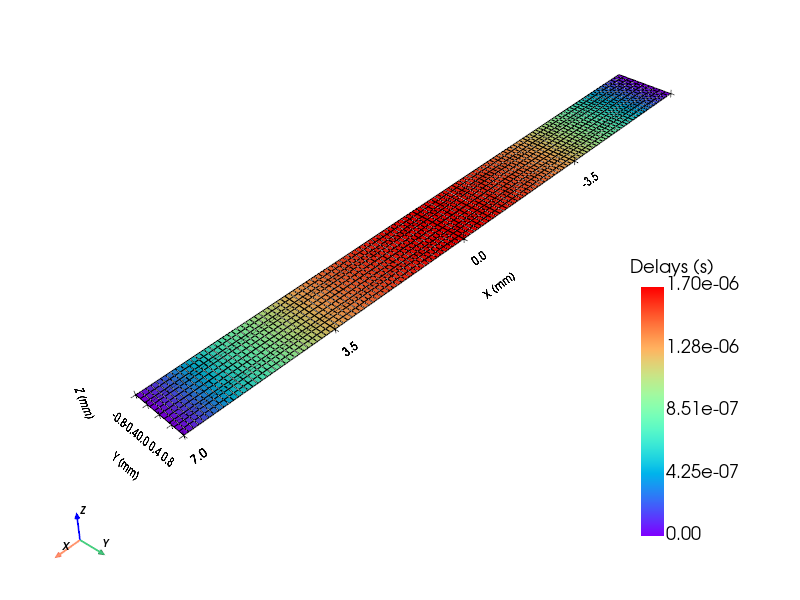

In [6]:
# ------------------ Saving / options -----------------------
frequency_MHz = 12.5
c = 1540.0  # m/s
FoverD = 1 #

#  ------------------- transducer characteristics --------------------
tx_N_elements = 128
tx_element_height_mm = 1.5
tx_width_mm = 0.108
tx_pitch_mm = 0.11
tx_kerf_mm = tx_pitch_mm - tx_width_mm
tx_elevationFocus_mm = 1000
tx_frequency_Hz = frequency_MHz * 1e6
no_sub_x = 1
no_sub_y = 10

# Create transducer     
Linear_transducer = transducers.LinearArrayTransducer(
        n_elements=tx_N_elements,
        element_width_mm=tx_width_mm,
        element_height_mm=tx_element_height_mm,
        elevation_focus_mm=tx_elevationFocus_mm,
        kerf_mm=tx_kerf_mm,
        no_sub_x=no_sub_x,
        no_sub_y=no_sub_y,
        frequency_Hz=tx_frequency_Hz,
    )

Linear_transducer.compute_delays(focus_mm=focus_mm)
Linear_transducer.compute_apodization(focus_mm=focus_mm, FoverD=FoverD)
Linear_transducer.show(scalars='Delays', notebook = True, jupyter_backend='static')

#### Matrix

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.

Transducer initialized in 0.0660 seconds.


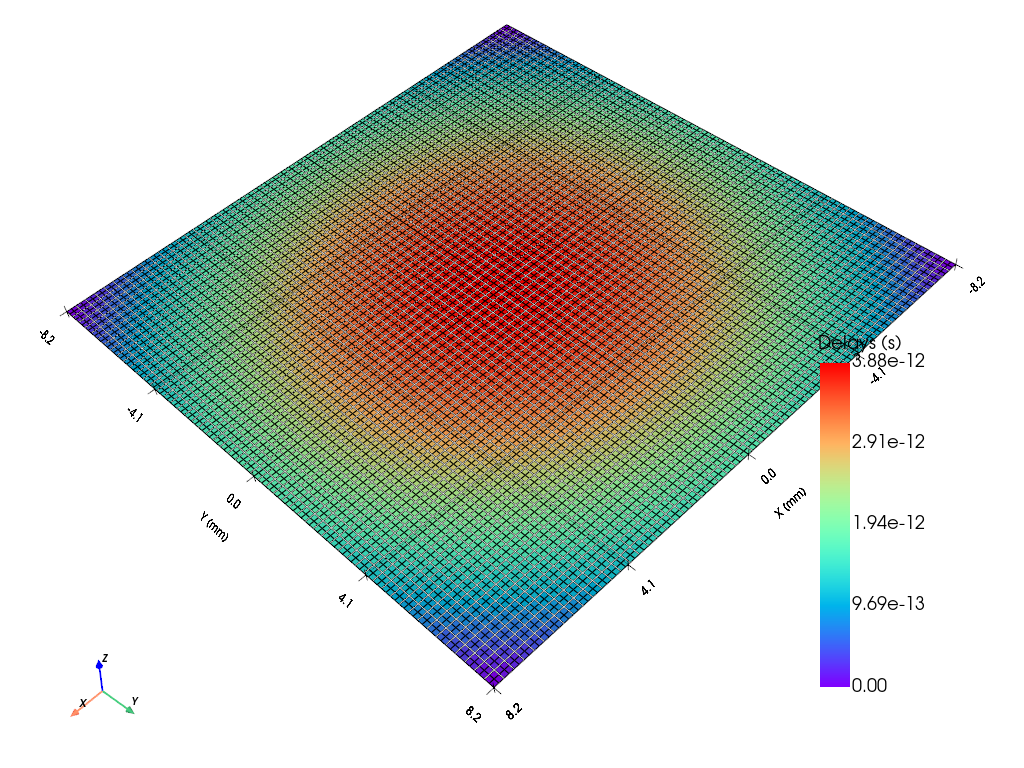

In [8]:
# ------------------ Saving / options -----------------------
frequency_MHz = 10
c = 1540.0  # m/s
FoverD = 1 #

#  ------------------- transducer characteristics --------------------
tx_N_elem_x = 55
tx_N_elem_y = 55
tx_elem_width_mm = 0.29
tx_elem_height_mm = 0.29
tx_pitch_mm = 0.3
tx_kerf_x_mm = tx_pitch_mm - tx_elem_width_mm
tx_kerf_y_mm = tx_pitch_mm - tx_elem_height_mm
tx_frequency_Hz = frequency_MHz * 1e6  # MHz
no_sub_x = 2
no_sub_y = 2

# Create transducer     
Matrix_transducer = transducers.MatrixArrayTransducer(
        N_elem_x=tx_N_elem_x,
        N_elem_y=tx_N_elem_y,
        elem_width_mm=tx_elem_width_mm,
        elem_height_mm=tx_elem_height_mm,
        kerf_x_mm=tx_kerf_x_mm,
        kerf_y_mm=tx_kerf_y_mm,
        no_sub_x=no_sub_x,
        no_sub_y=no_sub_x,
        frequency_Hz=tx_frequency_Hz,  # MHz),
    )

Matrix_transducer.compute_delays(focus_mm=focus_mm)
Matrix_transducer.compute_apodization(focus_mm=focus_mm, FoverD=FoverD)
Matrix_transducer.show(scalars='Delays', notebook = True, jupyter_backend='static')

### 2.2.3. Perform simulations

In [9]:
# from pyfield.psimulation import TorchField

Matrix_field = PyField(Matrix_transducer)
x_m,y_m,z_m, pr_pyfield_matrix = Matrix_field(field_info_matrix_mm, method = 'SDI', normalize=True)

Min distance must be >> w^2/(4*lambda): 0.0341 mm

Computing SIR for 132651 points and 12100 patches with method SDI...
Min distance: 7.00 mm, Max distance: 15.21 mm
Computed time grid from 4.50 us to 13.85 us, with 1871 samples in 2.22 seconds.
Adjusted t0 :  4.50e-06->8.19e-06 s, and tN : 1.38e-05 -> 9.95e-06 s, 
 h_sir size: 132651 x 353 (was 132651 x 1871)
Transducer SIR computed in 8.609 seconds...
Monochromatic pressure computed from SIR in 0.22 seconds...
Pressure field computed in 9.53 seconds... 



In [10]:
x_m,y_m,z_m, pr_pyfield_matrix = Matrix_field(field_info_matrix_mm, method = 'SDI', normalize=True)


Computing SIR for 132651 points and 12100 patches with method SDI...
Min distance: 7.00 mm, Max distance: 15.21 mm
Computed time grid from 4.50 us to 13.85 us, with 1871 samples in 0.46 seconds.
Adjusted t0 :  4.50e-06->8.19e-06 s, and tN : 1.38e-05 -> 9.95e-06 s, 
 h_sir size: 132651 x 353 (was 132651 x 1871)
Transducer SIR computed in 3.184 seconds...
Monochromatic pressure computed from SIR in 0.22 seconds...
Pressure field computed in 4.17 seconds... 



In [11]:
Linear_field = PyField(Linear_transducer)
x_l,y_l,z_l, pr_pyfield_linear = Linear_field(field_info_linear_mm, method = 'SDI', normalize=True)

Min distance must be >> w^2/(4*lambda): 0.0457 mm

Computing SIR for 1030301 points and 1280 patches with method SDI...
Min distance: 7.00 mm, Max distance: 11.76 mm
Computed time grid from 4.51 us to 9.42 us, with 984 samples in 0.39 seconds.
Adjusted t0 :  4.51e-06->6.15e-06 s, and tN : 9.42e-06 -> 7.69e-06 s, 
 h_sir size: 1030301 x 309 (was 1030301 x 984)
Transducer SIR computed in 3.458 seconds...
Monochromatic pressure computed from SIR in 1.46 seconds...
Pressure field computed in 5.51 seconds... 



In [12]:
x_l,y_l,z_l, pr_pyfield_linear = Linear_field(field_info_linear_mm, method = 'SDI', normalize=True)


Computing SIR for 1030301 points and 1280 patches with method SDI...
Min distance: 7.00 mm, Max distance: 11.76 mm
Computed time grid from 4.51 us to 9.42 us, with 984 samples in 0.38 seconds.
Adjusted t0 :  4.51e-06->6.15e-06 s, and tN : 9.42e-06 -> 7.69e-06 s, 
 h_sir size: 1030301 x 309 (was 1030301 x 984)
Transducer SIR computed in 3.692 seconds...
Monochromatic pressure computed from SIR in 1.47 seconds...
Pressure field computed in 5.78 seconds... 



## 2.3. Comparison between FIELDII and PyField

In [13]:
pr_fieldii_matrix = mat_matrix['pr']/np.max(mat_matrix['pr'])
pr_fieldii_linear = mat_linear['pr']/np.max(mat_linear['pr'])

In [14]:
print("Matlab time for matrix field : ", mat_matrix['h_calc_time'])
print("Matlab time for Linear field : ", mat_linear['h_calc_time'])

Matlab time for matrix field :  247.954171
Matlab time for Linear field :  101.9293686


### 2.3.1. 2D Planes

Taking slice (0.0e+00,0.0e+00,8.0e+00) mm => x_ind, y_ind, z_ind = 51/101, 51/101, 51/101


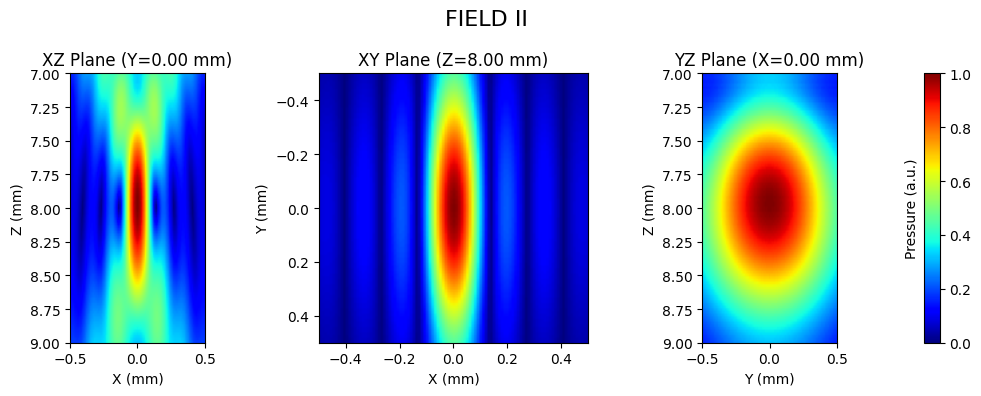

Taking slice (0.0e+00,0.0e+00,8.0e+00) mm => x_ind, y_ind, z_ind = 51/101, 51/101, 51/101


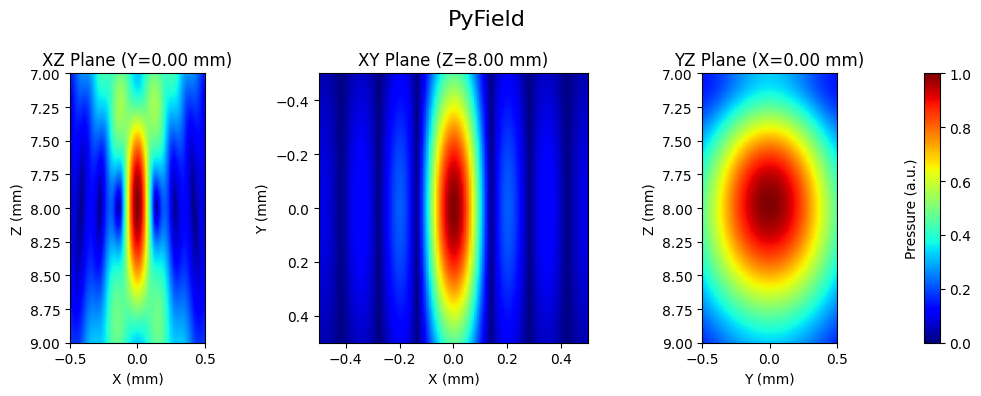

In [15]:
pyfield.plot_field_planes(x_l,y_l,z_l, pr_fieldii_linear, vmin = 0, vmax = 1, figsize = (10,4), title="FIELD II")
pyfield.plot_field_planes(x_l,y_l,z_l, pr_pyfield_linear, vmin = 0, vmax = 1, figsize = (10,4), title="PyField")
# pyfield.plot_field_planes(x_l,y_l,z_l, np.abs(pr_pyfield_linear-pr_fieldii_linear), figsize = (10,4), title="Absolute error")

Taking slice (0.0e+00,0.0e+00,8.0e+00) mm => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


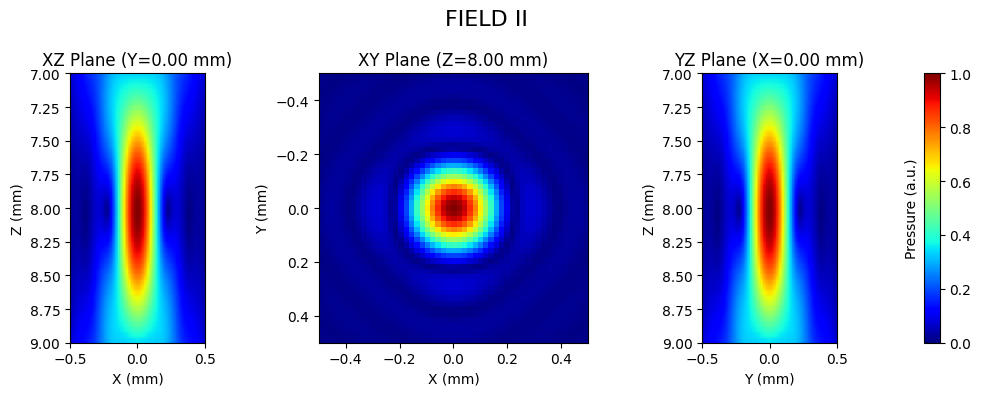

Taking slice (0.0e+00,0.0e+00,8.0e+00) mm => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


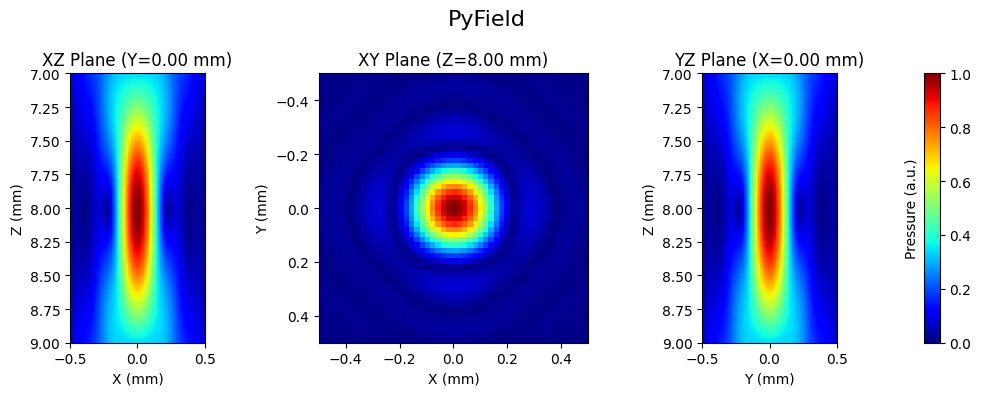

In [16]:
pyfield.plot_field_planes(x_m,y_m,z_m, pr_fieldii_matrix, vmin = 0, vmax = 1, figsize = (10,4), title="FIELD II")
pyfield.plot_field_planes(x_m,y_m,z_m, pr_pyfield_matrix, vmin = 0, vmax = 1, figsize = (10,4), title="PyField")
# pyfield.plot_field_planes(x_m,y_m,z_m, np.abs(pr_pyfield_matrix-pr_fieldii_matrix), figsize = (10,4), title="Absolute error")

### 2.3.2. 3D Pressure field

In [17]:
def todB(A, min_val = -50):
    return 20 * np.log10(np.abs(A+10**(min_val/20)))


In [61]:

# General settings
scale = 3
title1 = "Pressure (a.u.)"
title2 = "Absolute \n Difference (dB)"
scalar_bar_args1 =  {
                "title": title1,
                "title_font_size": int(20 * scale),
                "label_font_size": int(18 * scale),
                "vertical": True,
                "position_x": 0.8,
                "position_y": 0.6,
                "height": 0.3,
            }

scalar_bar_args2=  {
                "title": title2,
                "title_font_size": int(20 * scale),
                "label_font_size": int(16 * scale),
                "vertical": True,
                "position_x": 0.8,
                "position_y": 0.6,
                "height": 0.3,
            }

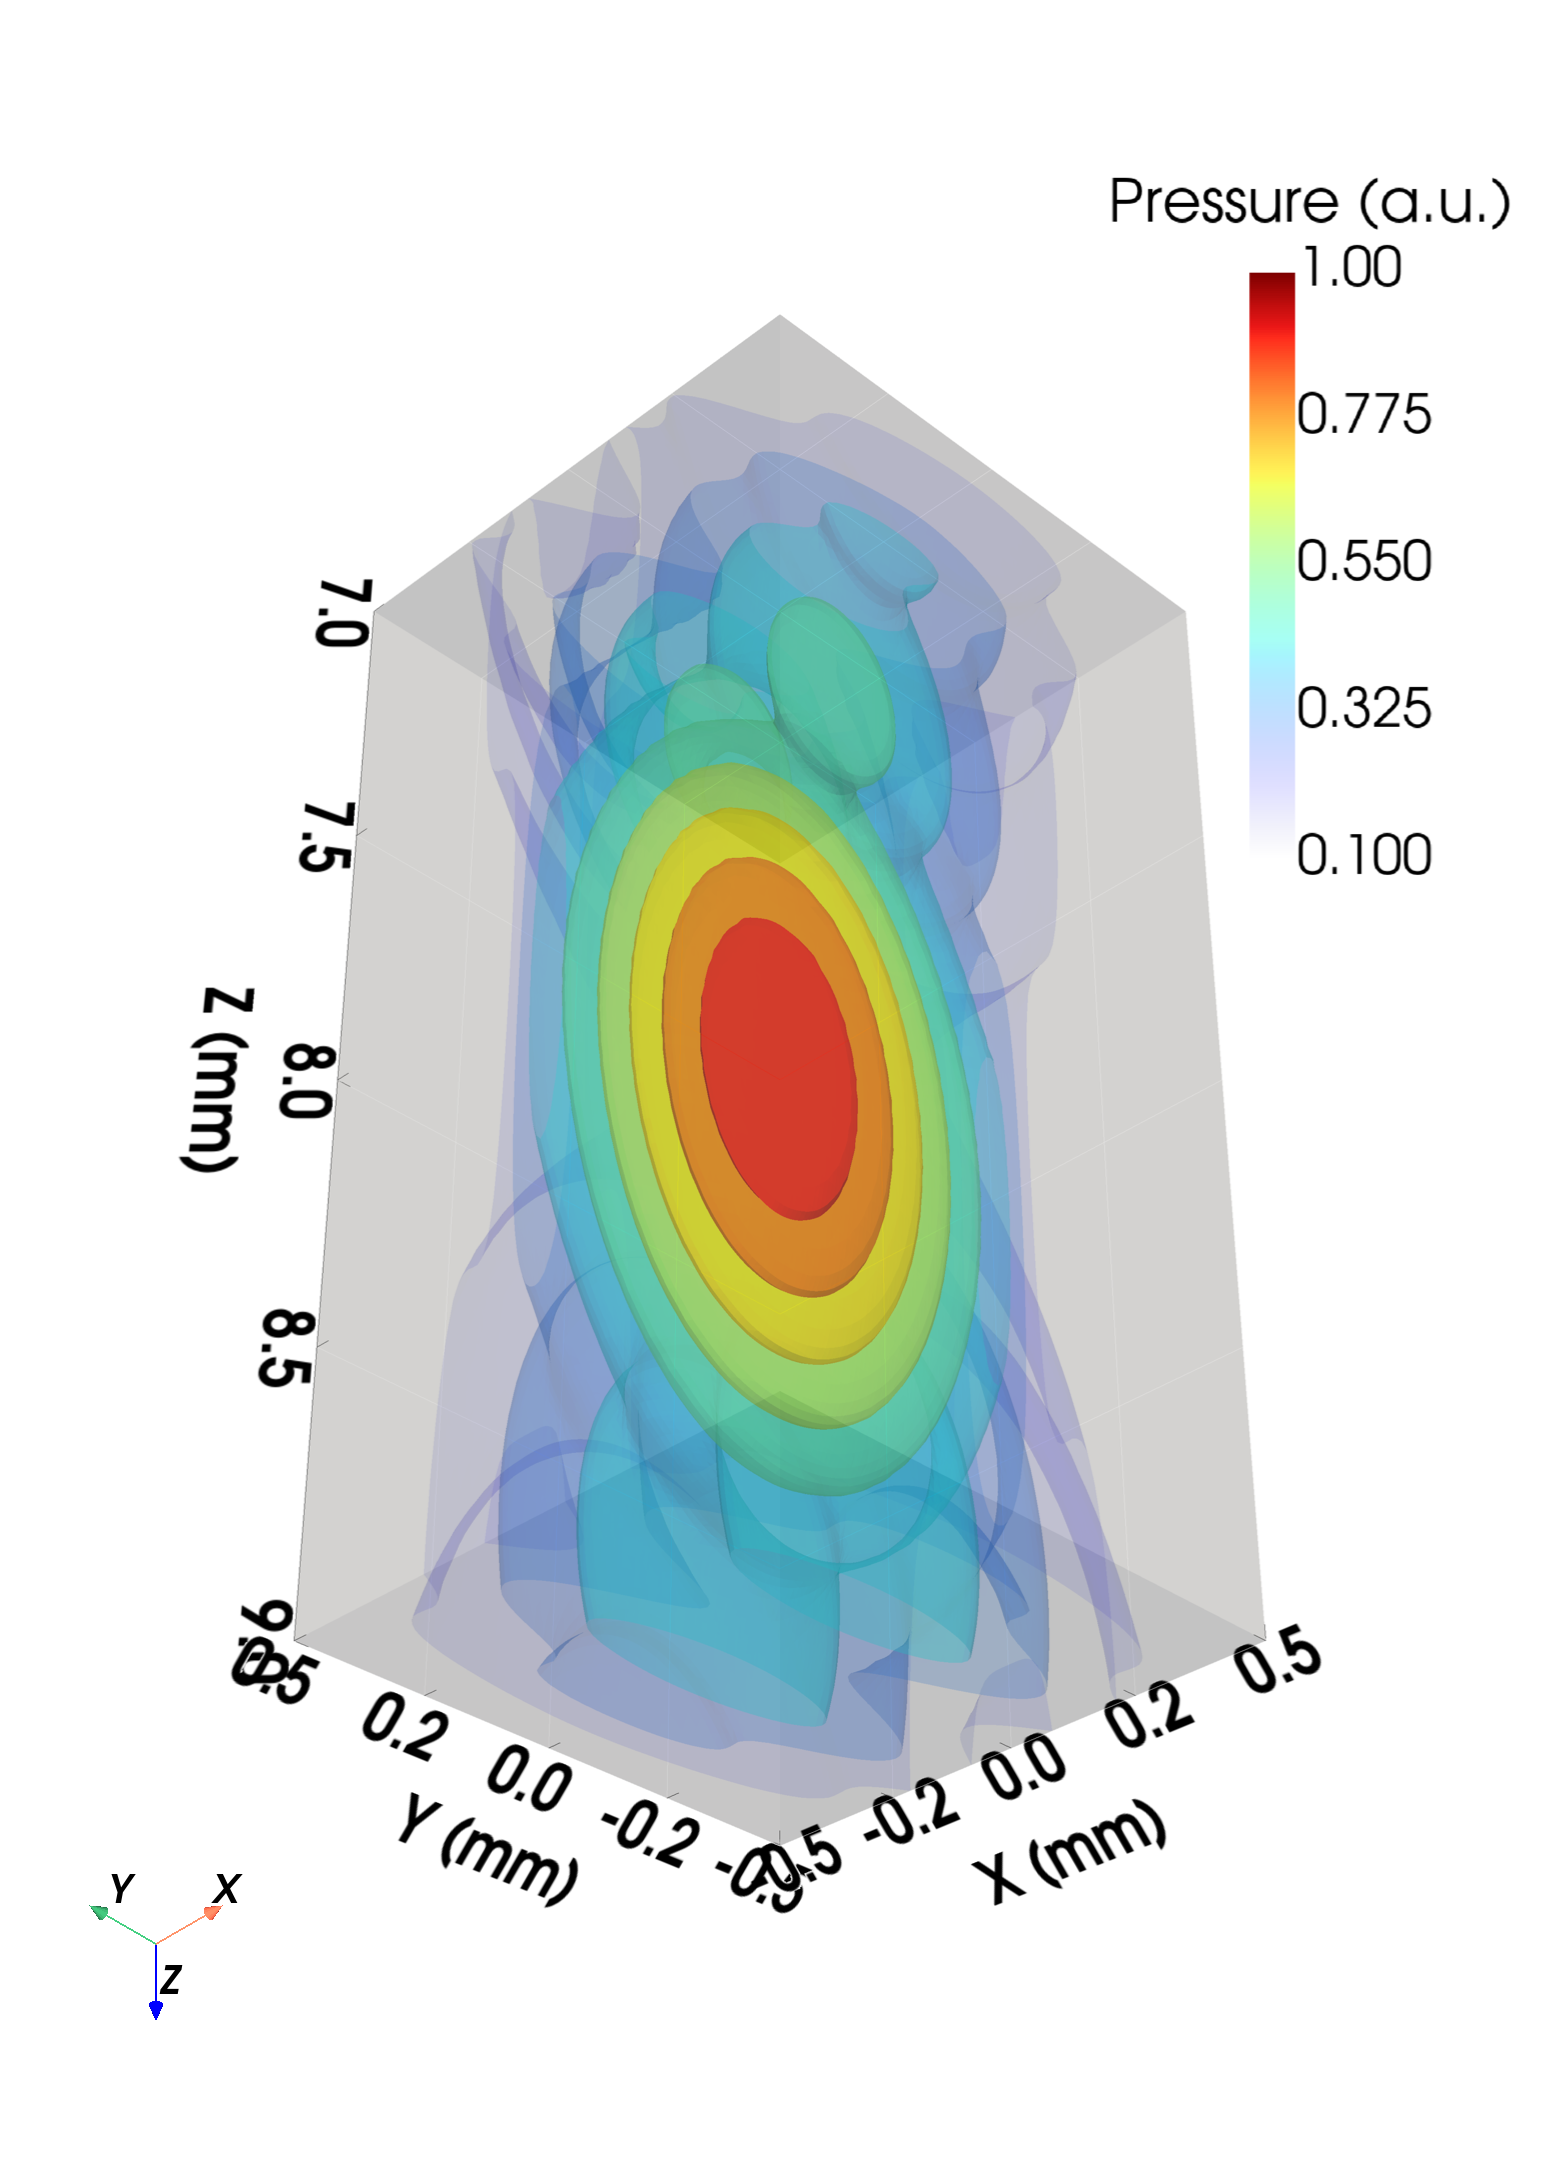

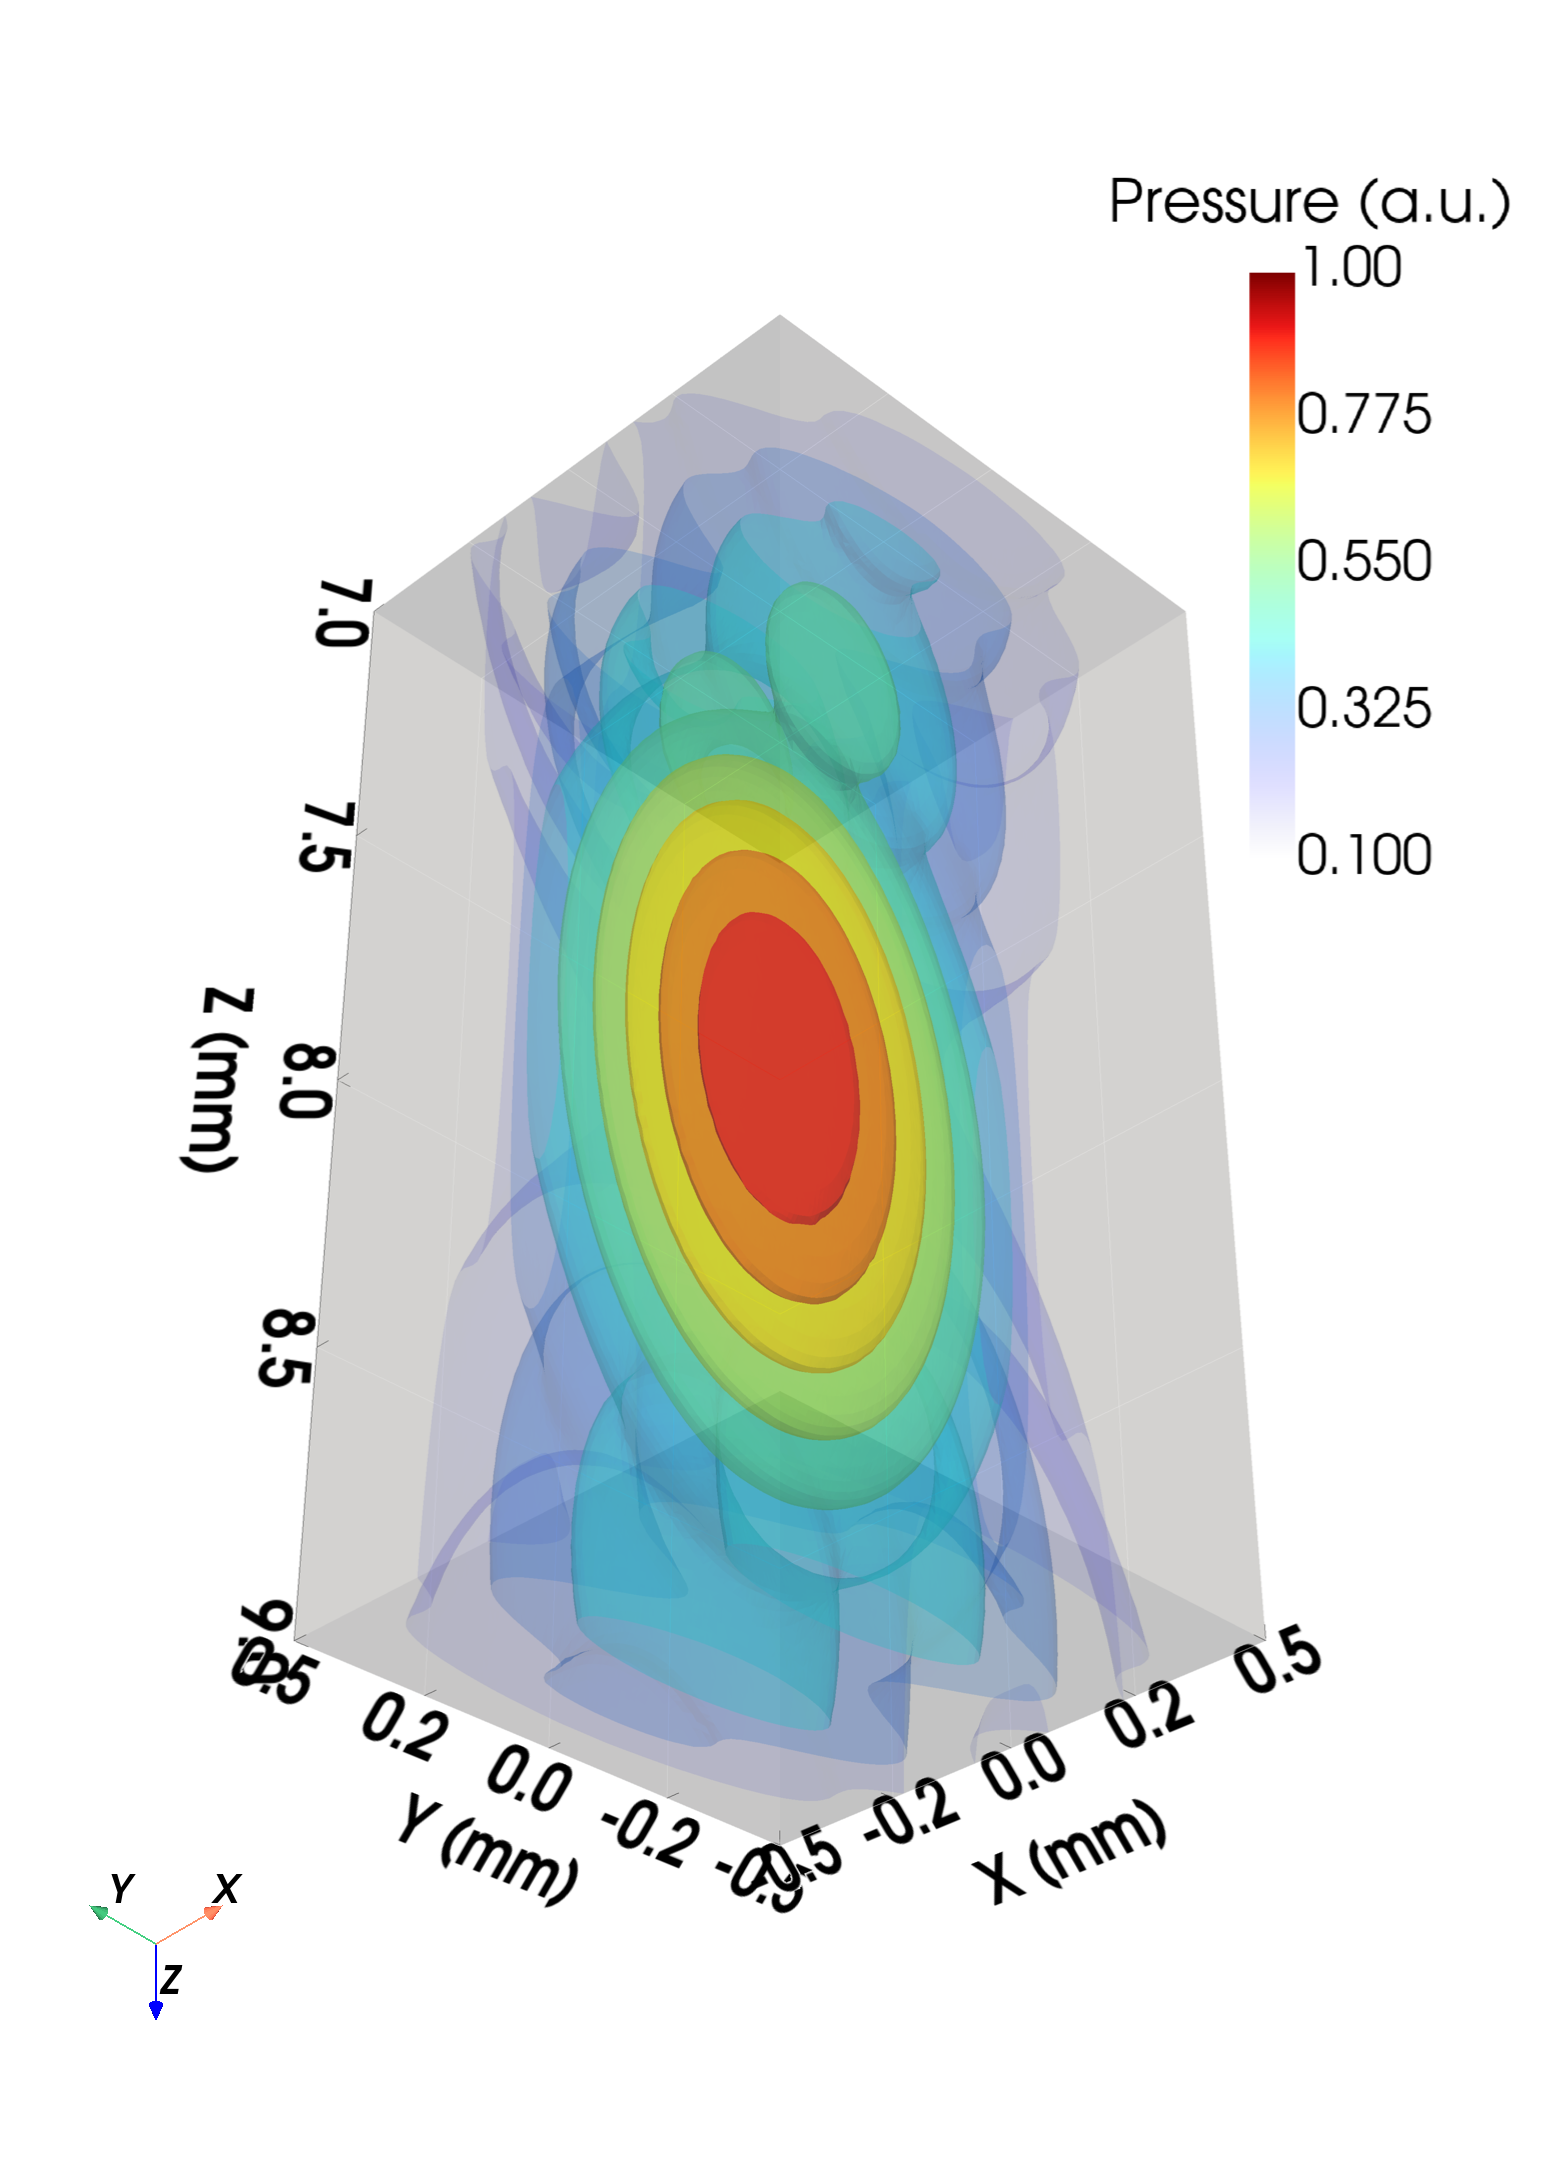

In [62]:
vmin = 0
vmax = 1
diff_linear_db = todB(pr_pyfield_linear - pr_fieldii_linear)

# plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, todB(pr_fieldii_linear), notebook=True, vmin=vmin, vmax=vmax, scale = scale, scalar_bar_args = scalar_bar_args1)
# plotter.show(jupyter_backend='static')
# plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, todB(pr_pyfield_linear), notebook=True, vmin=vmin, vmax=vmax, scale=scale, scalar_bar_args = scalar_bar_args1)
# plotter.show(jupyter_backend='static')


plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, pr_fieldii_linear, notebook=True, vmin=vmin, vmax=vmax, scalars = "Pressure (a.u.)", scale = scale, scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')
plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, pr_pyfield_linear, notebook=True, vmin=vmin, vmax=vmax, scalars = "Pressure (a.u.)", scale=scale, scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')


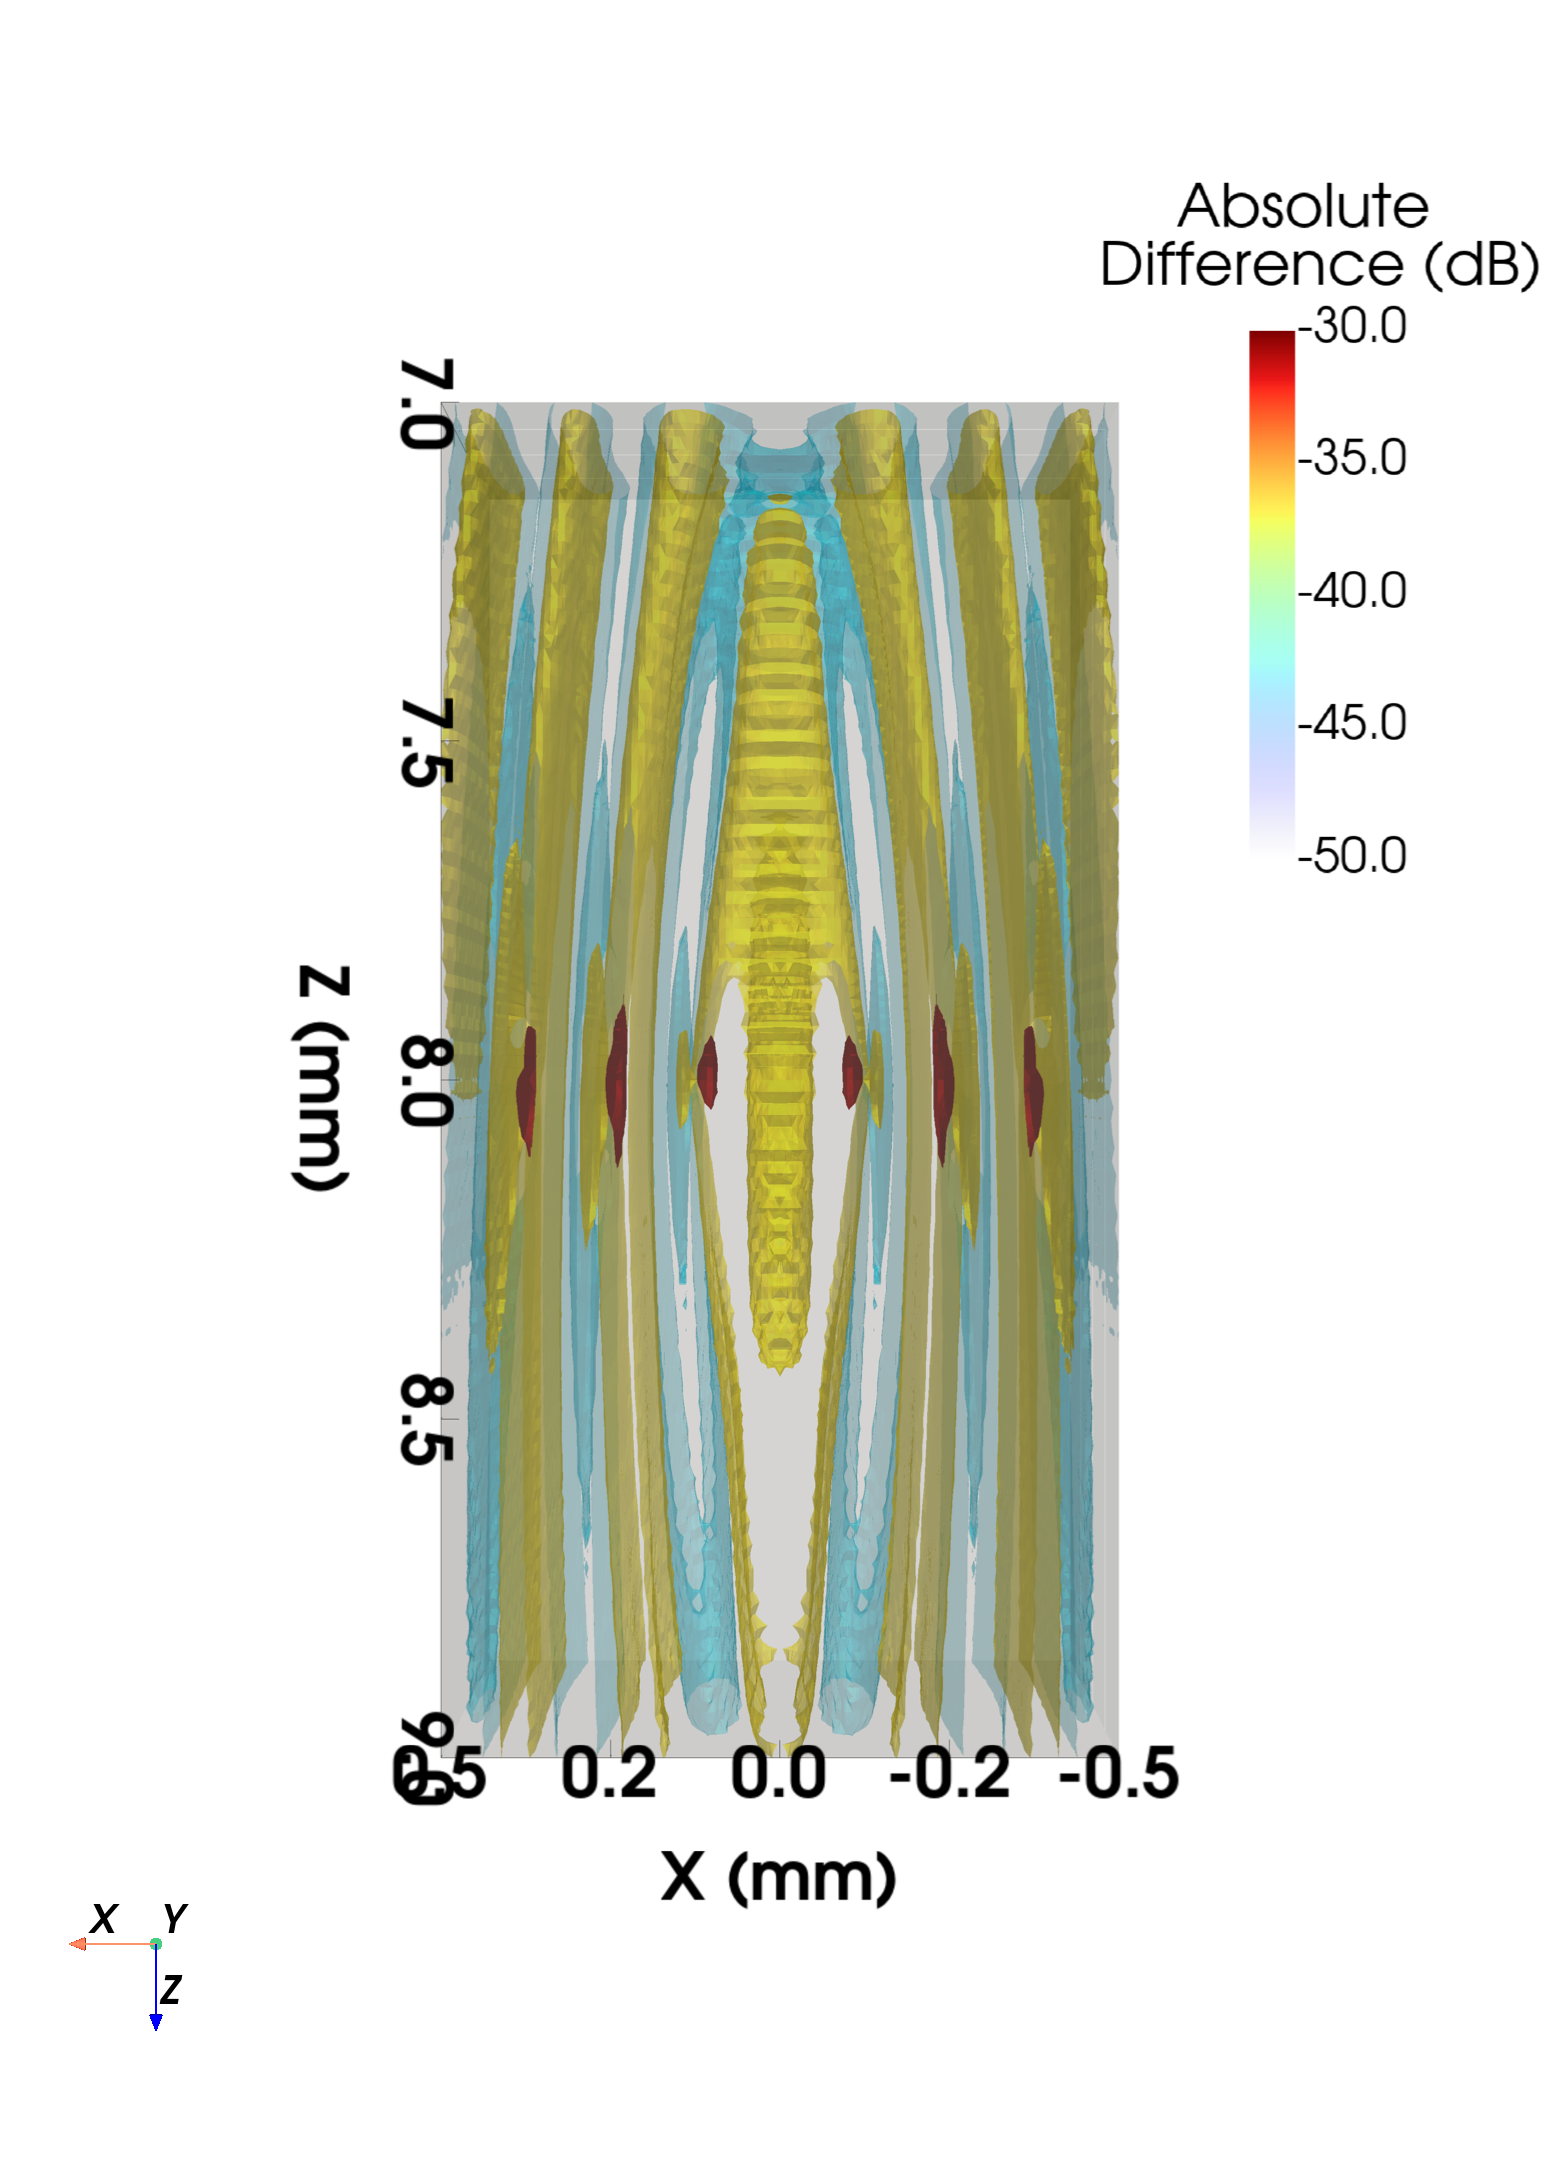

In [63]:

plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, diff_linear_db, notebook=True, vmin=-50, vmax=-30, contour_levels = 4, scale=scale, scalar_bar_args = scalar_bar_args2)
plotter.camera_position = 'xz'
plotter.camera.up = (0, 0, -1)
plotter.show(jupyter_backend='static')
# plotter.show()

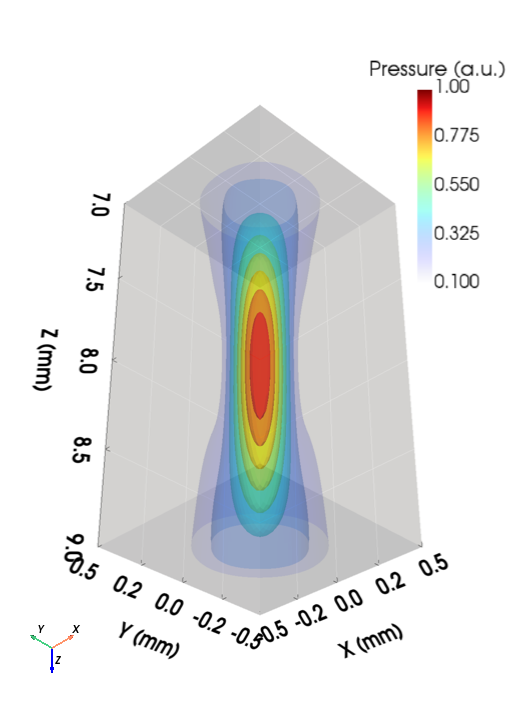

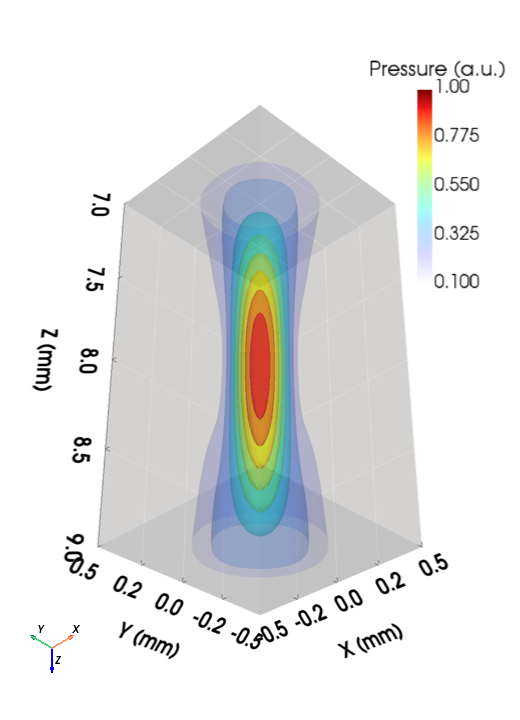

In [51]:

diff_matrix_db = todB(pr_pyfield_matrix - pr_fieldii_matrix)

# plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, todB(pr_fieldii_matrix), notebook=True, vmin=vmin, vmax=0, scale = scale, scalars = "Pressure (dB)", scalar_bar_args = scalar_bar_args1)
# plotter.show(jupyter_backend='static')
# plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, todB(pr_pyfield_matrix), notebook=True, vmin=vmin, vmax=0, scale=scale, scalars = "Pressure (dB)", scalar_bar_args = scalar_bar_args1)
# plotter.show(jupyter_backend='static')

plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, pr_fieldii_matrix, notebook=True, vmin=vmin, vmax=vmax, scale=scale, scalars = "Pressure (a.u.)", scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')
plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, pr_pyfield_matrix, notebook=True, vmin=vmin, vmax=vmax, scale=scale, scalars = "Pressure (a.u.)", scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')


 Difference (dB)' instead of 'Pressure'. Proceeding with 'Absolute 
 Difference (dB)'.


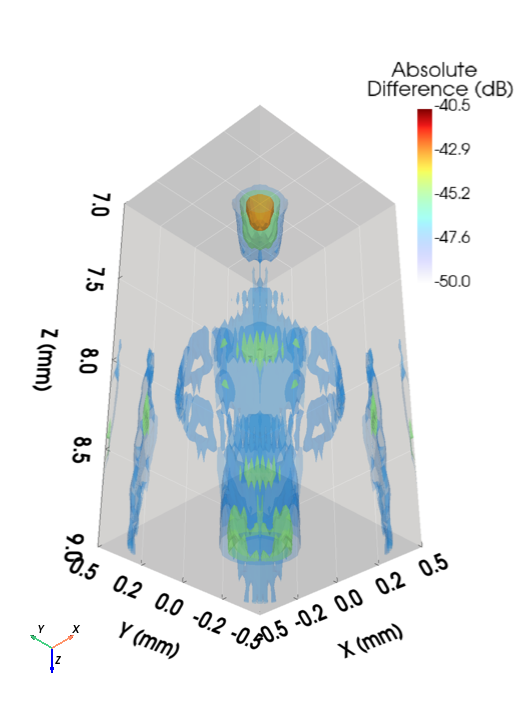

In [52]:
plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, diff_matrix_db, notebook=True, vmin=-50,contour_levels=5, scale=scale, scalars = "Absolute \n Difference (dB)", scalar_bar_args = scalar_bar_args2)

# plotter.camera_position = 'xz'
# plotter.camera.up = (0, 0, -1)
plotter.show(jupyter_backend='static')

### 2.3.3. 2D transient profile

In [3]:
pr_fieldii_linear_pulsed = np.transpose(mat_linear_pulsed['pr']/np.max(mat_linear_pulsed['pr']), (3, 2, 1, 0))
meanhcalc_time_fieldii_linear_pulsed = mat_linear_pulsed['mean_time'][0][0]
stdhcalc_time_fieldii_linear_pulsed = mat_linear_pulsed['std_time'][0][0]

In [21]:
pr_fieldii_linear_pulsed.shape

(2634, 641, 1, 561)

In [4]:
# ------------------ Saving / options -----------------------
frequency_MHz = 12.5
c = 1540.0  # m/s
sampling_frequency_MHz = 200  # MHz

# ------- focus and simulation window (input parameters) -------
x_extent_mm = [-8, 8]
y_extent_mm = [0, 0]
z_extent_mm = [1, 15]
dxyz1_mm = 0.025  # mm
dxyz2_mm = 0.01  # mm
focus_mm = [0.0, 0.0, 8]

#  ------------------- transducer characteristics --------------------
tx_N_elements = 128
tx_element_height_mm = 1.5
tx_width_mm = 0.108
tx_pitch_mm = 0.11
tx_kerf_mm = tx_pitch_mm - tx_width_mm
tx_elevationFocus_mm = 8.0
tx_frequency_Hz = frequency_MHz * 1e6
no_sub_x = 1
no_sub_y = 10


# ------- Create transducer (Linear array equivalent) -------
tx = transducers.LinearArrayTransducer(
    n_elements=tx_N_elements,
    element_width_mm=tx_width_mm,
    element_height_mm=tx_element_height_mm,
    elevation_focus_mm=tx_elevationFocus_mm,
    kerf_mm=tx_kerf_mm,
    no_sub_x=no_sub_x,
    no_sub_y=no_sub_y,
    frequency_Hz=tx_frequency_Hz,
)

# Optional: compute/aply delays / apodization
delays = tx.compute_delays(focus_mm=focus_mm)

# -------- DEFINE GRID (keep odd-number-of-points logic) --------

# Use PyField API which accepts extents + spacing (same style as notebook)
field_info1_mm = {
    "x_extent": x_extent_mm,
    "y_extent": y_extent_mm,
    "z_extent": z_extent_mm,
    "dx": dxyz1_mm,
    "dy": dxyz1_mm,
    "dz": dxyz1_mm,
}
field_info2_mm = {
    "x_extent": x_extent_mm,
    "y_extent": y_extent_mm,
    "z_extent": z_extent_mm,
    "dx": dxyz2_mm,
    "dy": dxyz2_mm,
    "dz": dxyz2_mm,
}


LinearArrayTransducer initialized in 0.0094 seconds.


In [5]:
# ------------------ Compute the field --------------------
field_solver = PyField(tx, fs=sampling_frequency_MHz * 1e6, c=c, monochromatic=False)

# first computation includes setup time for compiling and
# optimizing kernels. Subsequent it wont be counted.\

x1, y1, z1, pr_auto_pulsed1 = field_solver(field_info1_mm, method="auto")
x1, y1, z1, pr_sdi_pulsed1 = field_solver(field_info1_mm, method="sdi")
x1, y1, z1, pr_naive_pulsed1 = field_solver(field_info1_mm, method="naive")


Min distance must be >> w^2/(4*lambda): 0.0457 mm

Computing SIR for 359601 points and 1280 patches with method auto...
Min distance: 1.00 mm, Max distance: 21.20 mm
Computed time grid from 0.61 us to 15.55 us, with 2988 samples in 1.38 seconds.
Adjusted t0 :  6.11e-07->6.41e-07 s, and tN : 1.55e-05 -> 1.38e-05 s, 
 h_sir size: 359601 x 2632 (was 359601 x 2988)
Transducer SIR computed in 8.346 seconds...
Pressure with shape (2632, 641, 1, 561) computed from SIR in 0.81 seconds...
Pressure field computed in 9.35 seconds... 


Computing SIR for 359601 points and 1280 patches with method sdi...
Min distance: 1.00 mm, Max distance: 21.20 mm
Computed time grid from 0.61 us to 15.55 us, with 2988 samples in 0.13 seconds.
Adjusted t0 :  6.11e-07->6.41e-07 s, and tN : 1.55e-05 -> 1.38e-05 s, 
 h_sir size: 359601 x 2632 (was 359601 x 2988)
Transducer SIR computed in 5.619 seconds...
Pressure with shape (2632, 641, 1, 561) computed from SIR in 0.86 seconds...
Pressure field computed in 6.67 seco

In [6]:

repetition = 1
for rep in range(repetition):
    x1, y1, z1, pr_naive_pulsed1 = field_solver(field_info1_mm, method="naive", normalize=True)

for rep in range(repetition):
    x1, y1, z1, pr_sdi_pulsed1 = field_solver(field_info1_mm, method="sdi", normalize=True)

for rep in range(repetition):
    x1, y1, z1, pr_auto_pulsed1 = field_solver(field_info1_mm, method="auto", normalize=True)

#  Simulations for the second grid (finer spacing)

for rep in range(repetition):
    x2, y2, z2, pr_naive_pulsed2 = field_solver(field_info2_mm, method="naive", normalize=True)

for rep in range(repetition):
    x2, y2, z2, pr_sdi_pulsed2 = field_solver(field_info2_mm, method="sdi", normalize=True)

for rep in range(repetition):
    x2, y2, z2, pr_auto_pulsed2 = field_solver(field_info2_mm, method="auto", normalize=True)


Computing SIR for 359601 points and 1280 patches with method naive...
Min distance: 1.00 mm, Max distance: 21.20 mm
Computed time grid from 0.61 us to 15.55 us, with 2988 samples in 0.12 seconds.
Adjusted t0 :  6.11e-07->6.41e-07 s, and tN : 1.55e-05 -> 1.38e-05 s, 
 h_sir size: 359601 x 2632 (was 359601 x 2988)
Transducer SIR computed in 2.670 seconds...
Pressure with shape (2632, 641, 1, 561) computed from SIR in 0.81 seconds...
Pressure field computed in 3.67 seconds... 


Computing SIR for 359601 points and 1280 patches with method sdi...
Min distance: 1.00 mm, Max distance: 21.20 mm
Computed time grid from 0.61 us to 15.55 us, with 2988 samples in 0.12 seconds.
Adjusted t0 :  6.11e-07->6.41e-07 s, and tN : 1.55e-05 -> 1.38e-05 s, 
 h_sir size: 359601 x 2632 (was 359601 x 2988)
Transducer SIR computed in 2.273 seconds...
Pressure with shape (2632, 641, 1, 561) computed from SIR in 0.89 seconds...
Pressure field computed in 3.36 seconds... 


Computing SIR for 359601 points and 128

In [7]:
# Take mean and std of pyfield calculation time
num_methods = 3
num_configurations = 2

hcalc_times_pyfield_linear_pulsed = field_solver.sir_running_time_log[3:] # ignore first 3 runs which include setup time

mean_pyfield_time_linear_pulsed = np.zeros(num_methods*num_configurations)
std_pyfield_time_linear_pulsed = np.zeros(num_methods*num_configurations)

for i in range(num_methods*num_configurations):
    mean_pyfield_time_linear_pulsed[i] = np.mean(hcalc_times_pyfield_linear_pulsed[i*repetition:(i+1)*repetition])
    std_pyfield_time_linear_pulsed[i] = np.std(hcalc_times_pyfield_linear_pulsed[i*repetition:(i+1)*repetition])


In [8]:
print(f"FIELD II pulsed linear calc time: {meanhcalc_time_fieldii_linear_pulsed:.3f} ± {stdhcalc_time_fieldii_linear_pulsed:.3f} s")
print("PyField pulsed linear calc time (mean ± std) in seconds:")
print("mean times (s): ", mean_pyfield_time_linear_pulsed)
print("std times (s): ", std_pyfield_time_linear_pulsed)

FIELD II pulsed linear calc time: 51.478 ± 0.514 s
PyField pulsed linear calc time (mean ± std) in seconds:
mean times (s):  [ 2.66991043  2.27269268  2.64119744 20.39723086 18.5688765  26.56214619]
std times (s):  [0. 0. 0. 0. 0. 0.]


In [ ]:
# Create function to plot field
def todB(A, min_val = -50):
    return 20 * np.log10(np.abs(A+10**(min_val/20)))

plt.rcParams.update({'font.size': 14})

def plot_pulsed_field_comparison(grids, pressures,*,titles = None, selected_methods=None, 
                                 selected_idx_times=[0, -1], f_sampling_MHz=200, 
                                 dB = True, vmin= -50, vmax = 0, xlim=None, ylim=None):
    """
    Plot comparison between FIELDII and PyField methods at selected time steps.
    
    Parameters:
    -----------
    grid : list
        List containing coordinate arrays for pressure fields with 'x', 'y', 'z' arrays
        Coordinate arrays for the field
    pr_fieldii : list
        List containing pressure fields to plot with 'pr' array (time, x, y, z)
    titles : list
        List of titles for each method (length should match number of methods being compared)
    compare_no_methods : int
        Number of methods to compare (max number of methods to compare is length of grid and pressure lists)
    selected_idx_times : list
        List of time indices to plot
    f_sampling_MHz : float
        Sampling frequency in MHz
    """
    len_pressure = len(pressures)
    if len(grids) != len_pressure:
        raise ValueError("Length of grids and pressures lists must be the same.")
    
    if selected_methods is None:
        selected_methods = list(range(len_pressure))
        no_methods = len_pressure
    else:
        selected_methods = list(selected_methods)  # Convert to list
        no_methods = len(selected_methods)
        try:
            if no_methods < 1:
                print("compare_no_methods must be at least 1. Setting to compare all methods.")
                selected_methods = list(range(len_pressure))
            elif max(selected_methods) >= len_pressure:
                print(f"compare_no_methods cannot be greater than the number of pressure fields ({len_pressure}). Setting to compare all methods.")
                selected_methods = list(range(len_pressure))
        except ValueError:
            print("Invalid value for compare_no_methods. Setting to compare all methods.")
            selected_methods = list(range(len_pressure))


    # Determine number of columns and rows
    n_cols = no_methods
    n_rows = len(selected_idx_times)
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    
    # Ensure axes is 2D
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Prepare method data in order: FIELDII, then SDI, Naive, Auto (depending on compare_no_methods)
    # Check temporal dimension of each pressure field and select the appropriate time indices
    min_common_time_idx = float('inf')
    for i in selected_methods:
        pr = pressures[i]
        time_dim = pr.shape[0]
        if time_dim < min_common_time_idx:
            min_common_time_idx = time_dim
    
    # Convert negative indices to positive
    idx_times = [i if i < min_common_time_idx else min_common_time_idx + i for i in selected_idx_times]
    
    times_us = 1/f_sampling_MHz * np.array(selected_idx_times)  # in us
    print("Selected time indices (us): ", times_us)

    if titles is None:
        titles = [f"Method {i+1}" for i in range(len_pressure)]

    # Plot each selected time step
    for row, t_idx in enumerate(idx_times):
        for col, method_idx in enumerate(selected_methods):
            method_name = titles[method_idx]
            pr = pressures[method_idx]
            ax = axes[row, col]
            x, y, z = grids[method_idx]['x'], grids[method_idx]['y'], grids[method_idx]['z']
            # Extract 2D slice at the y=0 plane
            if pr.ndim == 3:
                # Shape: (time, x, z)
                data = np.squeeze(pr[t_idx, :, :]).T
            else:
                # Shape: (time, x, y, z) - standard case
                data = np.squeeze(pr[t_idx, :, 0, :]).T
            
            # Plot
            if dB:
                data = todB(data)

            im = ax.imshow(data, extent=(x[0], x[-1], z[-1], z[0]), cmap="jet", vmin=vmin, vmax=vmax)

            if row == 0:
                ax.set_title(method_name)
            # ax.set_title(f"{method_name} - t_idx={t_idx}")

            if row == n_rows-1:
                ax.set_xlabel("x (mm)")
            if col == 0:
                ax.set_ylabel("z (mm)")
            
            if xlim is not None:
                ax.set_xlim(xlim)
            if ylim is not None:
                ax.set_ylim(ylim)
            if col != 0:
                # Turn off the y-axis ticks for the last column
                ax.yaxis.set_ticks([])
            if row != n_rows - 1:
                # Turn off the x-axis ticks for all but the last row
                ax.xaxis.set_ticks([])
    
    # Adjust layout to make room for colorbar
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.1)  # Make room at bottom for colorbar
    
    # Add horizontal colorbar at bottom
    cbar = fig.colorbar(im, ax=axes, orientation='horizontal', pad=0.05, fraction=0.046, aspect=30)
    cbar.set_label("Pressure (dB)")
    
    plt.show()

    return fig



Selected time indices (us):  [ 2.5   5.    6.25  7.5  10.  ]


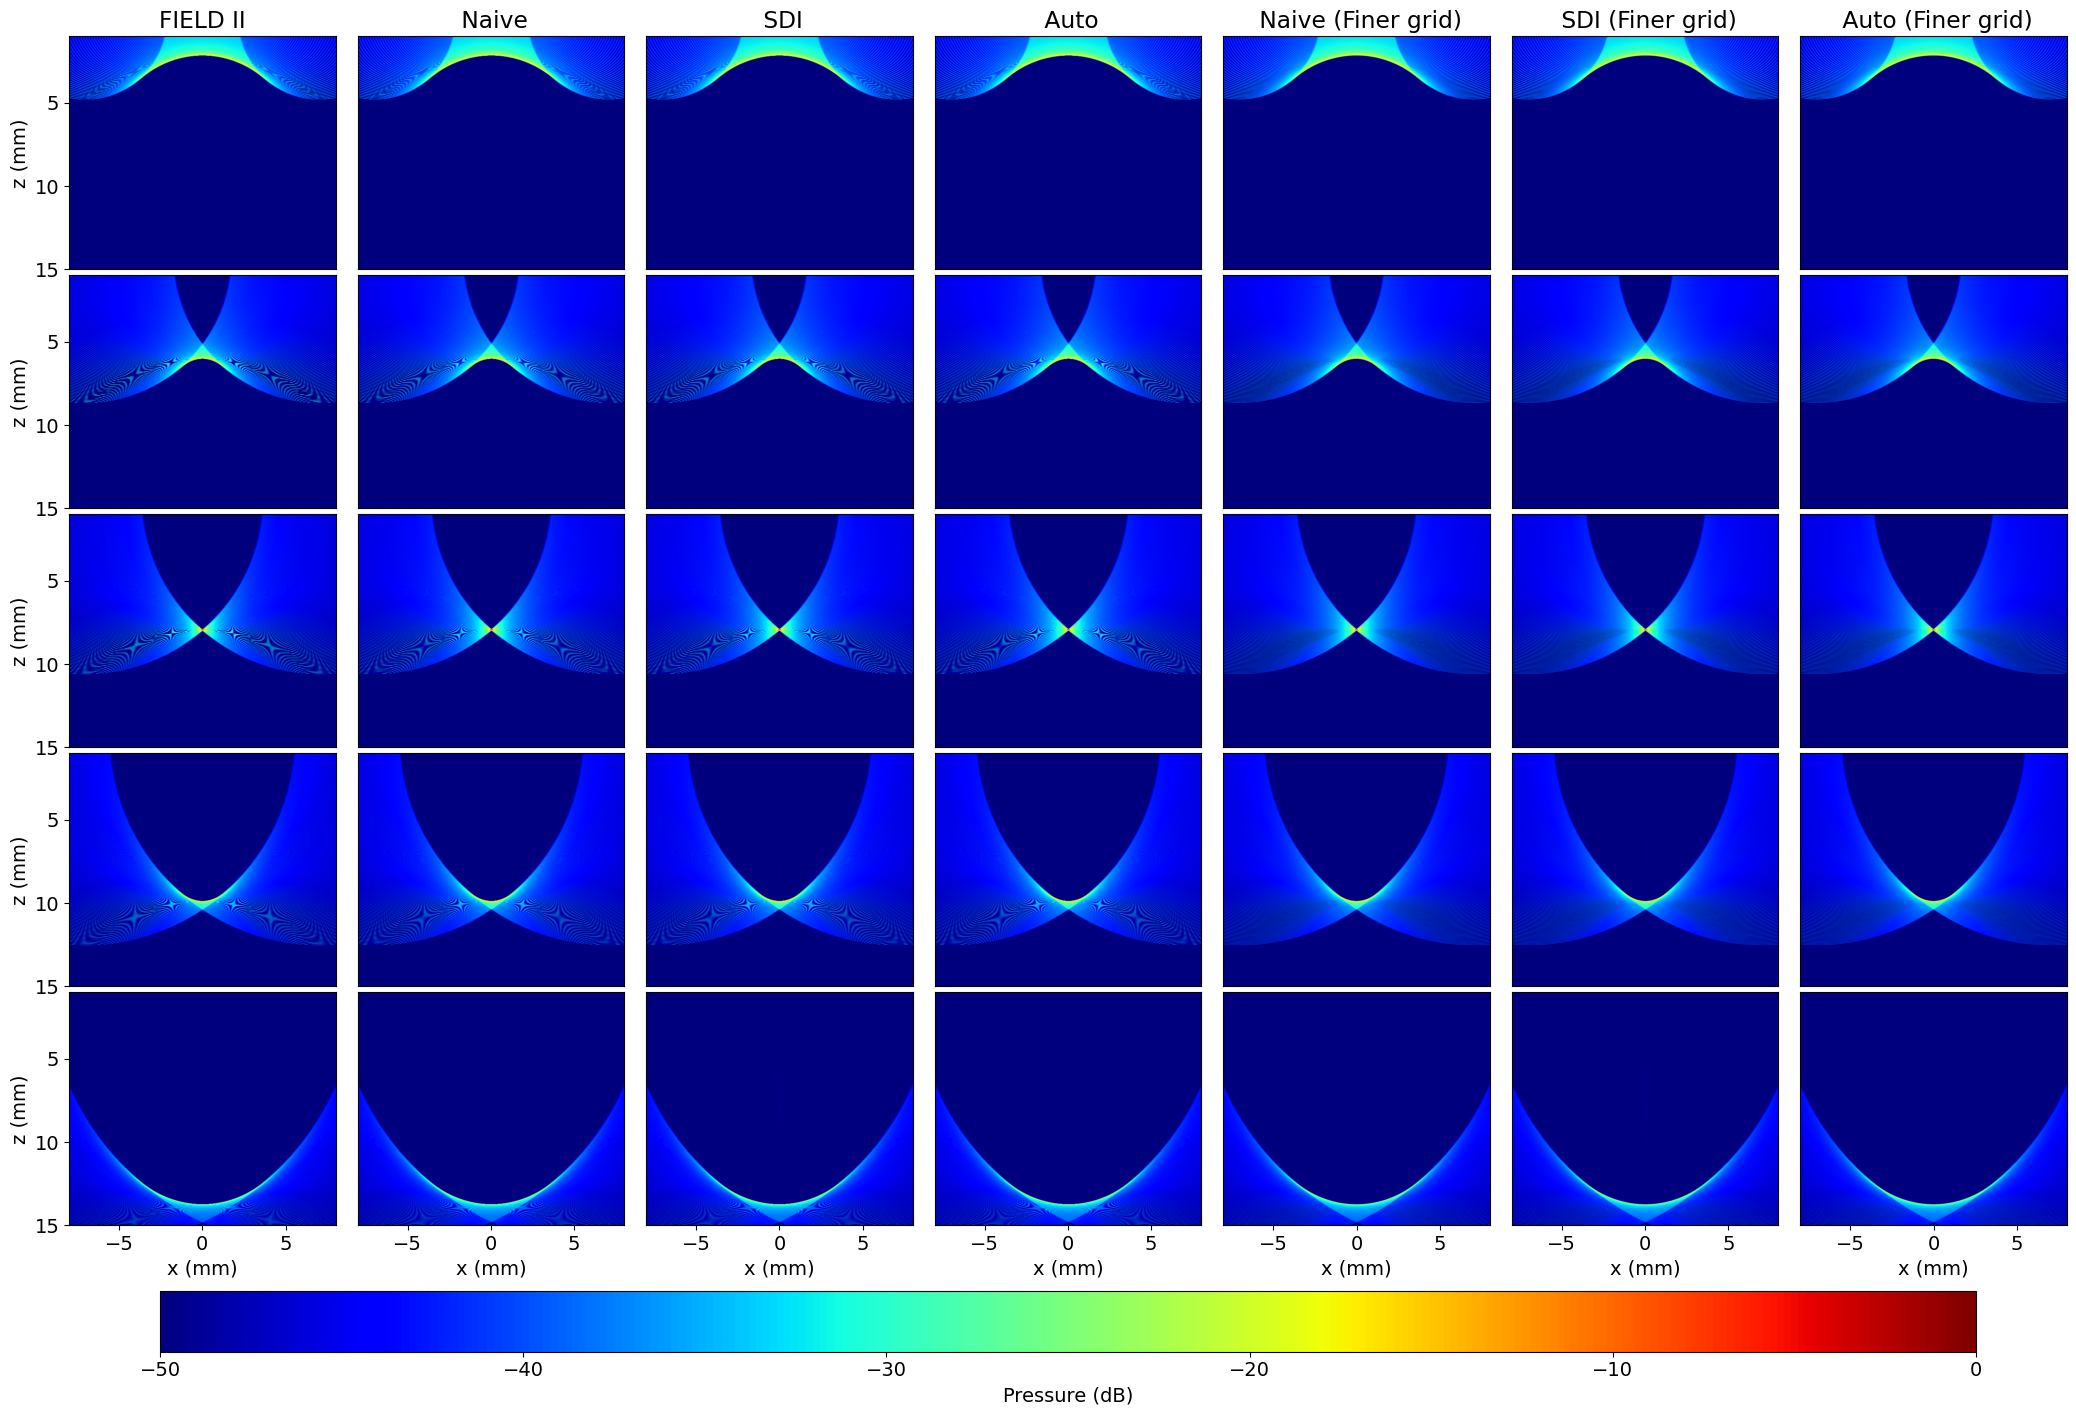

In [12]:
titles = [
    "FIELD II",
    " Naive",
    " SDI",
    " Auto",
    " Naive (Finer grid)",
    " SDI (Finer grid)",
    " Auto (Finer grid)",
]
grids = [
    {'x': x1, 'y': y1, 'z': z1},
    {'x': x1, 'y': y1, 'z': z1},
    {'x': x1, 'y': y1, 'z': z1},
    {'x': x1, 'y': y1, 'z': z1},
    {'x': x2, 'y': y2, 'z': z2},
    {'x': x2, 'y': y2, 'z': z2},
    {'x': x2, 'y': y2, 'z': z2},]

pressures = [
    pr_fieldii_linear_pulsed,
    pr_naive_pulsed1,
    pr_sdi_pulsed1,
    pr_auto_pulsed1,
    pr_naive_pulsed2,
    pr_sdi_pulsed2,
    pr_auto_pulsed2,
]



fig1 = plot_pulsed_field_comparison(grids, pressures, titles=titles, selected_idx_times=[500,1000, 1250,1500, 2000], f_sampling_MHz=sampling_frequency_MHz, dB = True)


Selected time indices (us):  [ 2.5   5.    6.25  7.5  10.  ]


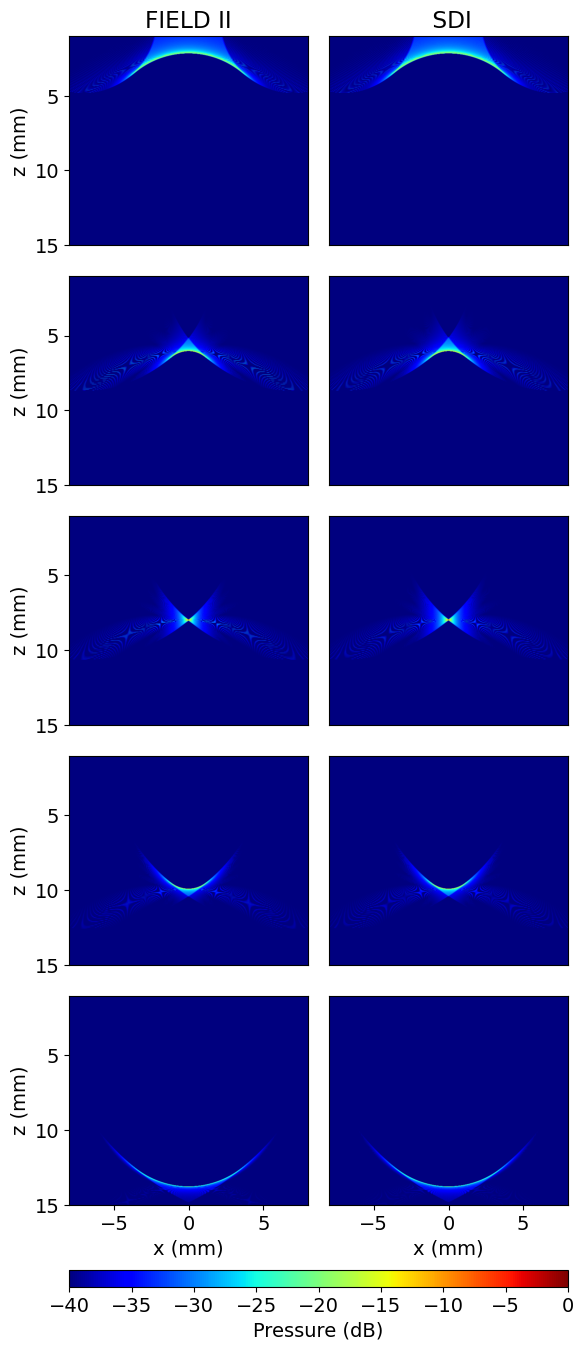

In [ ]:
selected_methods = [0, 2]  # FIELDII, PyField Auto (coarser grid), PyField Auto (finer grid)
fig2 = plot_pulsed_field_comparison(grids, pressures, titles=titles, selected_idx_times=[500,1000, 1250,1500, 2000], 
                                    selected_methods=selected_methods, f_sampling_MHz=sampling_frequency_MHz, 
                                    dB = True, vmin=-40, vmax=0, 
                                    xlim = (-5, 5), zlim=(2, 14))



In [ ]:
# fig1.savefig("pulsed_field_comparison_all.png", dpi=300)
# fig2.savefig("pulsed_field_comparison_selected.png", dpi=300)

In [ ]:

# fig1.savefig("pulsed_field_comparison_all.svg", dpi = 800)
# fig2.savefig("pulsed_field_comparison_selected.svg", dpi = 800)

In [ ]:
print(mat_linear_pulsed['P'])

[[359601.]]


In [ ]:
Points = [mat_linear_pulsed['P'][0][0].tolist()]+[field_solver.P_log[0]]*3 + [field_solver.P_log[-1]]*3
Temporal_samples = [mat_linear_pulsed['T'][0][0].tolist()]+ [field_solver.T_log[0]]*3 + [field_solver.T_log[-1]]*3
print("Points in the grid (P): ", Points)
print("Temporal samples in the grid (T): ", Temporal_samples)

Points in the grid (P):  [359601.0, 359601, 359601, 359601, 2243001, 2243001, 2243001]
Temporal samples in the grid (T):  [2634.0, 2988, 2988, 2988, 2988, 2988, 2988]


In [ ]:
# Make a small table with the calculation times for each method and configuration

import pandas as pd

# Create a DataFrame to hold the times
Points = [mat_linear_pulsed['P'][0][0].tolist()]+[field_solver.P_log[0]]*3 + [field_solver.P_log[-1]]*3
Temporal_samples = [mat_linear_pulsed['T'][0][0].tolist()]+ [field_solver.T_log[0]]*3 + [field_solver.T_log[-1]]*3
print("Points in the grid (P): ", Points)
print("Temporal samples in the grid (T): ", Temporal_samples)
# Number of points in the grid (same for all methods/configurations)

# Columns: Method, P, T, Mean Time (s), Std Time (s)
data = {
    "Method": ["FIELD II", "PyField Naive (coarser grid)", "PyField SDI (coarser grid)", "PyField Auto (coarser grid)", "PyField Naive (finer grid)", "PyField SDI (finer grid)", "PyField Auto (finer grid)"],
    "Points (P)": Points,
    "Temporal samples (T)": Temporal_samples,
    "Mean Time (s)": [meanhcalc_time_fieldii_linear_pulsed] + list(mean_pyfield_time_linear_pulsed),
    "Std Time (s)": [stdhcalc_time_fieldii_linear_pulsed] + list(std_pyfield_time_linear_pulsed),
}
df_times = pd.DataFrame(data)


Points in the grid (P):  [359601.0, 359601, 359601, 359601, 2243001, 2243001, 2243001]
Temporal samples in the grid (T):  [2634.0, 2988, 2988, 2988, 2988, 2988, 2988]


In [ ]:
df_times

,Method,Points (P),Temporal samples (T),Mean Time (s),Std Time (s)
0,FIELD II,359601.0,2634.0,51.478293,0.514195
1,PyField Naive (coarser grid),359601.0,2988.0,3.087742,0.496170
2,PyField SDI (coarser grid),359601.0,2988.0,2.314467,0.042132
3,PyField Auto (coarser grid),359601.0,2988.0,2.480914,0.045039
4,PyField Naive (finer grid),2243001.0,2988.0,22.340324,5.865113
5,PyField SDI (finer grid),2243001.0,2988.0,14.274786,1.530999
6,PyField Auto (finer grid),2243001.0,2988.0,18.106580,7.706158
